# LLM-as-Judge: Evaluating Scientific Analogies

This notebook evaluates the quality of top-1 analogies from multiple baseline systems using an LLM judge with structured scoring.


In [1]:
# =============================================================================
# SETUP: Imports and LLM Configuration
# =============================================================================
import sys
import os
import pandas as pd
import ast
from typing import List, Dict, Any, Optional
from tqdm import tqdm

# Add path to easy_llm_importer
sys.path.append('mapping_generation')
from easy_llm_importer import create_client, DSPyAdapter

import dspy

# Initialize LLM client and configure DSPy
client = create_client()
adapter = DSPyAdapter(client, "gpt-4.1-mini")
lm = adapter.get_dspy_lm()
dspy.configure(lm=lm)

print("DSPy configured with gpt-4.1-mini")
print(f"Available in context: {lm}")


DSPy configured with gpt-4.1-mini
Available in context: <dspy.clients.lm.LM object at 0x00000152F7F18110>


In [2]:
# =============================================================================
# DSPy SIGNATURE: Analogy Judge
# =============================================================================

JUDGE_INSTRUCTIONS = """You are an expert evaluator of scientific analogies.

Given a target concept and a chosen source analogy, evaluate whether this is a good analogy.
A good analogy uses a FAMILIAR source concept to explain an UNFAMILIAR target concept through meaningful structural or functional parallels.

Score each dimension from 1-3:

ANALOGY_COHERENCE: Does the pairing make intuitive sense?
- 3: Immediately clear why these concepts relate
- 2: Connection exists but requires explanation
- 1: No meaningful connection; random or forced pairing

MAPPING_SOUNDNESS: Could properties/mechanisms of the source map to the target?
- 3: Clear structural or functional parallels exist
- 2: Some mappings work, others are weak or forced
- 1: No valid mappings possible; analogy is superficial

EXPLANATORY_POWER: Would this analogy help a learner understand the target?
- 3: Illuminates the target concept effectively using familiar source
- 2: Provides partial insight but with limitations
- 1: Fails to aid understanding; may confuse rather than clarify
"""


class AnalogyJudgeSignature(dspy.Signature):
    __doc__ = JUDGE_INSTRUCTIONS
    
    target_concept: str = dspy.InputField(desc="The unfamiliar target concept being explained")
    chosen_analogy: str = dspy.InputField(desc="The source concept chosen as the analogy")
    selection_reasoning: str = dspy.InputField(desc="The reasoning used to select this analogy (empty if not available)")
    
    analogy_coherence: int = dspy.OutputField(desc="Score 1-3: Does the pairing make intuitive sense?")
    mapping_soundness: int = dspy.OutputField(desc="Score 1-3: Could source properties map to target properties?")
    explanatory_power: int = dspy.OutputField(desc="Score 1-3: Would this help a learner understand the target?")


print("AnalogyJudgeSignature defined with 3 scoring dimensions (1-3 scale):"
      "\n  - analogy_coherence"
      "\n  - mapping_soundness"
      "\n  - explanatory_power")


AnalogyJudgeSignature defined with 3 scoring dimensions (1-3 scale):
  - analogy_coherence
  - mapping_soundness
  - explanatory_power


In [3]:
# =============================================================================
# LOAD DATA: All baseline and pipeline result files
# =============================================================================

# File configurations: (path, top1_column, reasoning_column, has_reasoning)
FILE_CONFIGS = {
    "baseline1_embedding_top3": {
        "path": "../stage_2_Modular_solution/baselines/baseline1_embedding_top3.csv",
        "top1_col": "predicted_rank_1",
        "reasoning_col": None,
        "has_reasoning": False
    },
    "baseline2_embedding_llm": {
        "path": "../stage_2_Modular_solution/baselines/baseline2_embedding_llm.csv",
        "top1_col": "llm_selected_sources",  # This is a list, need to parse
        "reasoning_col": "reranker_reasoning",
        "has_reasoning": True
    },
    "baseline2b_name_only": {
        "path": "../stage_2_Modular_solution/baselines/baseline2b_name_only.csv",
        "top1_col": "llm_selected_sources",
        "reasoning_col": "reranker_reasoning",
        "has_reasoning": True
    },
    "baseline2c_full": {
        "path": "../stage_2_Modular_solution/baselines/baseline2c_full.csv",
        "top1_col": "llm_selected_sources",
        "reasoning_col": "reranker_reasoning",
        "has_reasoning": True
    },
    "baseline2d_name_desc": {
        "path": "../stage_2_Modular_solution/baselines/baseline2d_name_desc.csv",
        "top1_col": "llm_selected_sources",
        "reasoning_col": "reranker_reasoning",
        "has_reasoning": True
    },
    "pipeline_results": {
        "path": "../stage_2_Modular_solution/pipelines/pipeline_results.csv",
        "top1_col": "selected_sources",  # This is a list, need to parse
        "reasoning_col": "reranker_reasoning",
        "has_reasoning": True
    }
}


def safe_parse_list(val):
    """Safely parse a string representation of a list."""
    if pd.isna(val):
        return []
    if isinstance(val, list):
        return val
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except:
        return [str(val)]


def extract_top1(val):
    """Extract the first element from a list or return the value itself."""
    if pd.isna(val):
        return None
    if isinstance(val, list):
        return val[0] if val else None
    # Try parsing as list
    parsed = safe_parse_list(val)
    return parsed[0] if parsed else str(val)


def load_all_data():
    """Load all baseline files and extract relevant columns."""
    all_data = []
    
    for source_name, config in FILE_CONFIGS.items():
        print(f"\nLoading {source_name}...")
        try:
            df = pd.read_csv(config["path"])
            print(f"  Loaded {len(df)} rows")
            
            for idx, row in df.iterrows():
                # Extract top-1 analogy
                top1_val = row.get(config["top1_col"])
                chosen_analogy = extract_top1(top1_val)
                
                if chosen_analogy is None:
                    print(f"  Warning: Row {idx} has no top-1 analogy, skipping")
                    continue
                
                # Extract reasoning if available
                reasoning = ""
                if config["has_reasoning"] and config["reasoning_col"]:
                    reasoning = row.get(config["reasoning_col"], "")
                    if pd.isna(reasoning):
                        reasoning = ""
                
                record = {
                    "id": row.get("id", idx),
                    "source_file": source_name,
                    "target": row.get("target", ""),
                    "gold_source": row.get("gold_source", ""),
                    "chosen_analogy": chosen_analogy,
                    "selection_reasoning": str(reasoning)[:2000],  # Truncate long reasoning
                    "has_reasoning": config["has_reasoning"] and len(str(reasoning)) > 0
                }
                all_data.append(record)
                
        except FileNotFoundError:
            print(f"  ERROR: File not found: {config['path']}")
        except Exception as e:
            print(f"  ERROR loading {source_name}: {e}")
    
    return pd.DataFrame(all_data)


# Load all data
eval_data = load_all_data()
print(f"\n{'='*60}")
print(f"Total records to evaluate: {len(eval_data)}")
print(f"\nRecords per source file:")
print(eval_data['source_file'].value_counts())



Loading baseline1_embedding_top3...
  Loaded 400 rows

Loading baseline2_embedding_llm...
  Loaded 400 rows

Loading baseline2b_name_only...
  Loaded 400 rows

Loading baseline2c_full...
  Loaded 400 rows

Loading baseline2d_name_desc...
  Loaded 400 rows

Loading pipeline_results...
  Loaded 400 rows

Total records to evaluate: 2400

Records per source file:
source_file
baseline1_embedding_top3    400
baseline2_embedding_llm     400
baseline2b_name_only        400
baseline2c_full             400
baseline2d_name_desc        400
pipeline_results            400
Name: count, dtype: int64


In [4]:
# =============================================================================
# EVALUATION FUNCTION: Using DSPy ChainOfThought
# =============================================================================
import time

# Create the judge predictor with ChainOfThought for reasoning
analogy_judge = dspy.ChainOfThought(AnalogyJudgeSignature)

def evaluate_analogy(target: str, chosen_analogy: str, reasoning: str = "", max_retries: int = 3):
    """
    Evaluate a single analogy using the LLM judge.
    
    Returns:
        dict with scores and reasoning, or error info on failure
    """
    last_error = None
    
    for attempt in range(max_retries):
        try:
            result = analogy_judge(
                target_concept=target,
                chosen_analogy=chosen_analogy,
                selection_reasoning=reasoning if reasoning else "No reasoning provided"
            )
            
            # Extract scores (ensure they are integers in 1-3 range)
            coherence = int(result.analogy_coherence)
            mapping = int(result.mapping_soundness)
            explanatory = int(result.explanatory_power)
            
            # Clamp to valid range (1-3)
            coherence = max(1, min(3, coherence))
            mapping = max(1, min(3, mapping))
            explanatory = max(1, min(3, explanatory))
            
            # Calculate average
            avg_score = (coherence + mapping + explanatory) / 3
            
            return {
                "analogy_coherence": coherence,
                "mapping_soundness": mapping,
                "explanatory_power": explanatory,
                "average_score": round(avg_score, 2),
                "judge_reasoning": result.reasoning,
                "status": "success"
            }
            
        except Exception as e:
            last_error = str(e)
            if attempt < max_retries - 1:
                time.sleep((attempt + 1) * 2)  # Exponential backoff
    
    # All retries failed
    return {
        "analogy_coherence": None,
        "mapping_soundness": None,
        "explanatory_power": None,
        "average_score": None,
        "judge_reasoning": f"ERROR: {last_error}",
        "status": "error"
    }


# Test with a single example
test_result = evaluate_analogy(
    target="biological clock",
    chosen_analogy="car",
    reasoning="A clock measures time, similar to how the biological clock regulates internal rhythms."
)
print("Test evaluation result:")
for k, v in test_result.items():
    if k == "judge_reasoning":
        print(f"  {k}: {str(v)[:200]}...")
    else:
        print(f"  {k}: {v}")


Test evaluation result:
  analogy_coherence: 1
  mapping_soundness: 1
  explanatory_power: 1
  average_score: 1.0
  judge_reasoning: The analogy between a biological clock and a car is not immediately intuitive. While a clock directly relates to measuring and regulating time, a car is a complex machine primarily used for transporta...
  status: success


In [5]:
# =============================================================================
# PROCESS ALL FILES: Run LLM judge on all records
# =============================================================================

def process_all_evaluations(data: pd.DataFrame, save_interval: int = 50):
    """
    Process all records through the LLM judge.
    Saves intermediate results every save_interval records.
    """
    results = []
    errors = 0
    
    print(f"Processing {len(data)} records...")
    print("=" * 60)
    
    for idx, row in tqdm(data.iterrows(), total=len(data), desc="Evaluating analogies"):
        # Evaluate the analogy
        eval_result = evaluate_analogy(
            target=row["target"],
            chosen_analogy=row["chosen_analogy"],
            reasoning=row["selection_reasoning"]
        )
        
        # Check for gold match (case-insensitive partial match)
        gold = str(row["gold_source"]).lower().strip()
        chosen = str(row["chosen_analogy"]).lower().strip()
        gold_match = (gold in chosen) or (chosen in gold) or (gold == chosen)
        
        # Combine original data with evaluation results
        result_record = {
            "id": row["id"],
            "source_file": row["source_file"],
            "target": row["target"],
            "gold_source": row["gold_source"],
            "chosen_analogy": row["chosen_analogy"],
            "has_reasoning": row["has_reasoning"],
            "analogy_coherence": eval_result["analogy_coherence"],
            "mapping_soundness": eval_result["mapping_soundness"],
            "explanatory_power": eval_result["explanatory_power"],
            "average_score": eval_result["average_score"],
            "gold_match": gold_match,
            "judge_reasoning": eval_result["judge_reasoning"],
            "status": eval_result["status"]
        }
        results.append(result_record)
        
        if eval_result["status"] == "error":
            errors += 1
        
        # Save intermediate results
        if (idx + 1) % save_interval == 0:
            intermediate_df = pd.DataFrame(results)
            intermediate_df.to_csv("llm_judge_results_intermediate.csv", index=False)
            print(f"\n  Saved intermediate results ({idx + 1} records, {errors} errors)")
    
    print(f"\n{'='*60}")
    print(f"Completed! Total: {len(results)}, Errors: {errors}")
    
    return pd.DataFrame(results)


# Run the evaluation
results_df = process_all_evaluations(eval_data)


Processing 2400 records...


Evaluating analogies:   2%|▏         | 50/2400 [02:19<1:46:08,  2.71s/it]


  Saved intermediate results (50 records, 0 errors)


Evaluating analogies:   4%|▍         | 100/2400 [04:14<1:31:33,  2.39s/it]


  Saved intermediate results (100 records, 0 errors)


...


  Saved intermediate results (2300 records, 0 errors)


Evaluating analogies:  98%|█████████▊| 2350/2400 [2:17:54<03:15,  3.91s/it]


  Saved intermediate results (2350 records, 0 errors)


Evaluating analogies: 100%|██████████| 2400/2400 [2:21:12<00:00,  3.53s/it]


  Saved intermediate results (2400 records, 0 errors)

Completed! Total: 2400, Errors: 0


In [6]:
# =============================================================================
# SAVE RESULTS AND COMPUTE SUMMARY STATISTICS
# =============================================================================

# Save full results
output_path = "llm_judge_results.csv"
results_df.to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

# Remove intermediate file if it exists
import os
if os.path.exists("llm_judge_results_intermediate.csv"):
    os.remove("llm_judge_results_intermediate.csv")
    print("Removed intermediate file")

# Display sample results
print("\n" + "="*60)
print("SAMPLE RESULTS (first 5 rows)")
print("="*60)
display_cols = ["source_file", "target", "chosen_analogy", "analogy_coherence", 
                "mapping_soundness", "explanatory_power", "average_score", "gold_match"]
print(results_df[display_cols].head())


Results saved to: llm_judge_results.csv
Removed intermediate file

SAMPLE RESULTS (first 5 rows)
                source_file               target      chosen_analogy  \
0  baseline1_embedding_top3     biological clock               clock   
1  baseline1_embedding_top3            Biosphere           Ecosystem   
2  baseline1_embedding_top3   Respiratory system         respiration   
3  baseline1_embedding_top3  Spread of Pathogens               Crowd   
4  baseline1_embedding_top3         Gene editing  bacterial mutation   

   analogy_coherence  mapping_soundness  explanatory_power  average_score  \
0                  3                  3                  3           3.00   
1                  3                  3                  3           3.00   
2                  2                  1                  1           1.33   
3                  2                  2                  2           2.00   
4                  2                  2                  2           2.00   

   gold

In [7]:
# =============================================================================
# SUMMARY STATISTICS BY SOURCE FILE
# =============================================================================

# Filter to successful evaluations only
successful = results_df[results_df["status"] == "success"].copy()
print(f"Successful evaluations: {len(successful)} / {len(results_df)}")

# Compute summary statistics per source file
summary_stats = successful.groupby("source_file").agg({
    "analogy_coherence": ["mean", "std"],
    "mapping_soundness": ["mean", "std"],
    "explanatory_power": ["mean", "std"],
    "average_score": ["mean", "std"],
    "gold_match": ["sum", "mean"],  # sum = count of matches, mean = match rate
    "id": "count"
}).round(3)

# Flatten column names
summary_stats.columns = [f"{col[0]}_{col[1]}" for col in summary_stats.columns]
summary_stats = summary_stats.rename(columns={
    "id_count": "n_records",
    "gold_match_sum": "gold_matches",
    "gold_match_mean": "gold_match_rate"
})

print("\n" + "="*80)
print("SUMMARY STATISTICS BY SOURCE FILE")
print("="*80)
print(summary_stats.to_string())

# Overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)
print(f"Total records evaluated: {len(successful)}")
print(f"Average coherence:       {successful['analogy_coherence'].mean():.2f} (std: {successful['analogy_coherence'].std():.2f})")
print(f"Average mapping:         {successful['mapping_soundness'].mean():.2f} (std: {successful['mapping_soundness'].std():.2f})")
print(f"Average explanatory:     {successful['explanatory_power'].mean():.2f} (std: {successful['explanatory_power'].std():.2f})")
print(f"Average overall:         {successful['average_score'].mean():.2f} (std: {successful['average_score'].std():.2f})")
print(f"Gold match rate:         {successful['gold_match'].mean()*100:.1f}%")


Successful evaluations: 2400 / 2400

SUMMARY STATISTICS BY SOURCE FILE
                          analogy_coherence_mean  analogy_coherence_std  mapping_soundness_mean  mapping_soundness_std  explanatory_power_mean  explanatory_power_std  average_score_mean  average_score_std  gold_matches  gold_match_rate  n_records
source_file                                                                                                                                                                                                                                           
baseline1_embedding_top3                   2.055                  0.839                   1.832                  0.804                   1.710                  0.730               1.865              0.733            65            0.162        400
baseline2_embedding_llm                    2.845                  0.408                   2.575                  0.570                   2.520                  0.583               2.646   

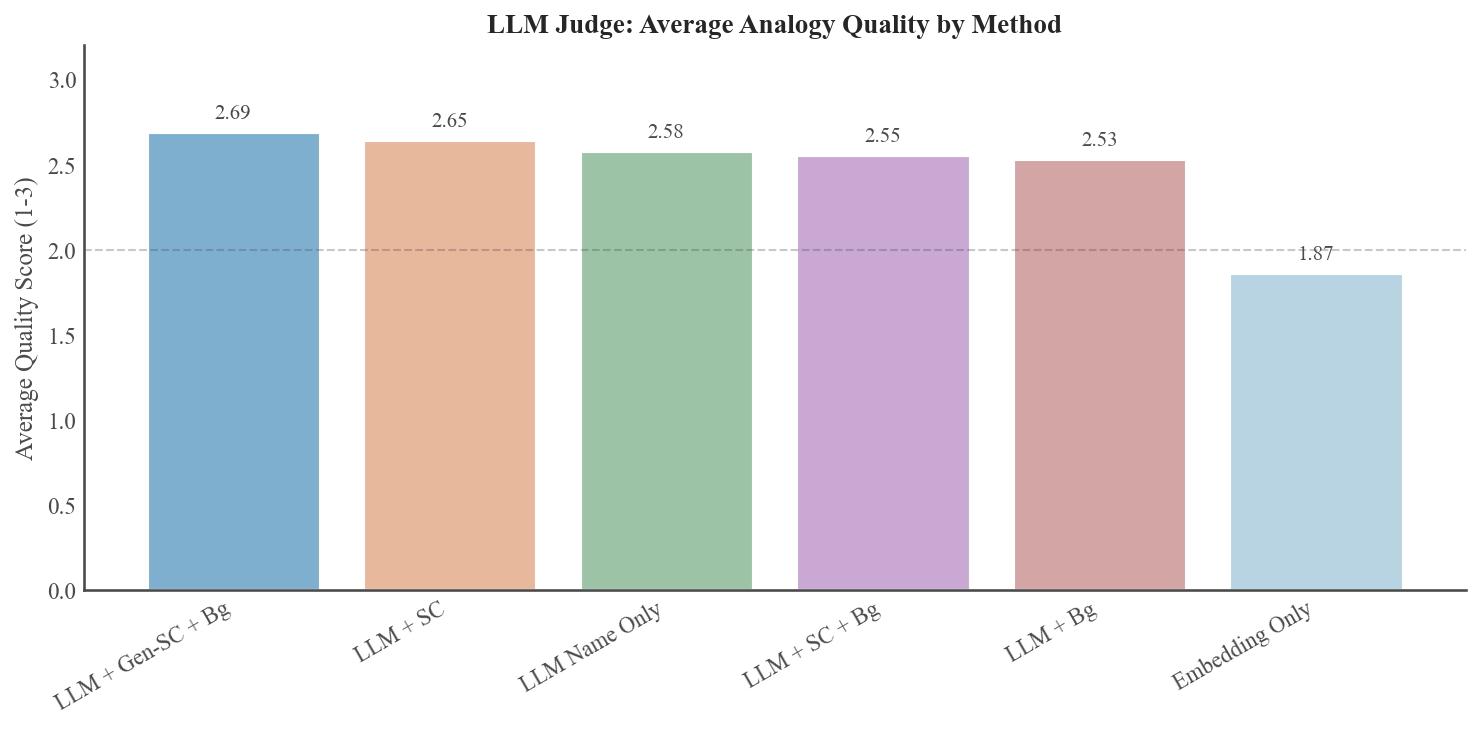

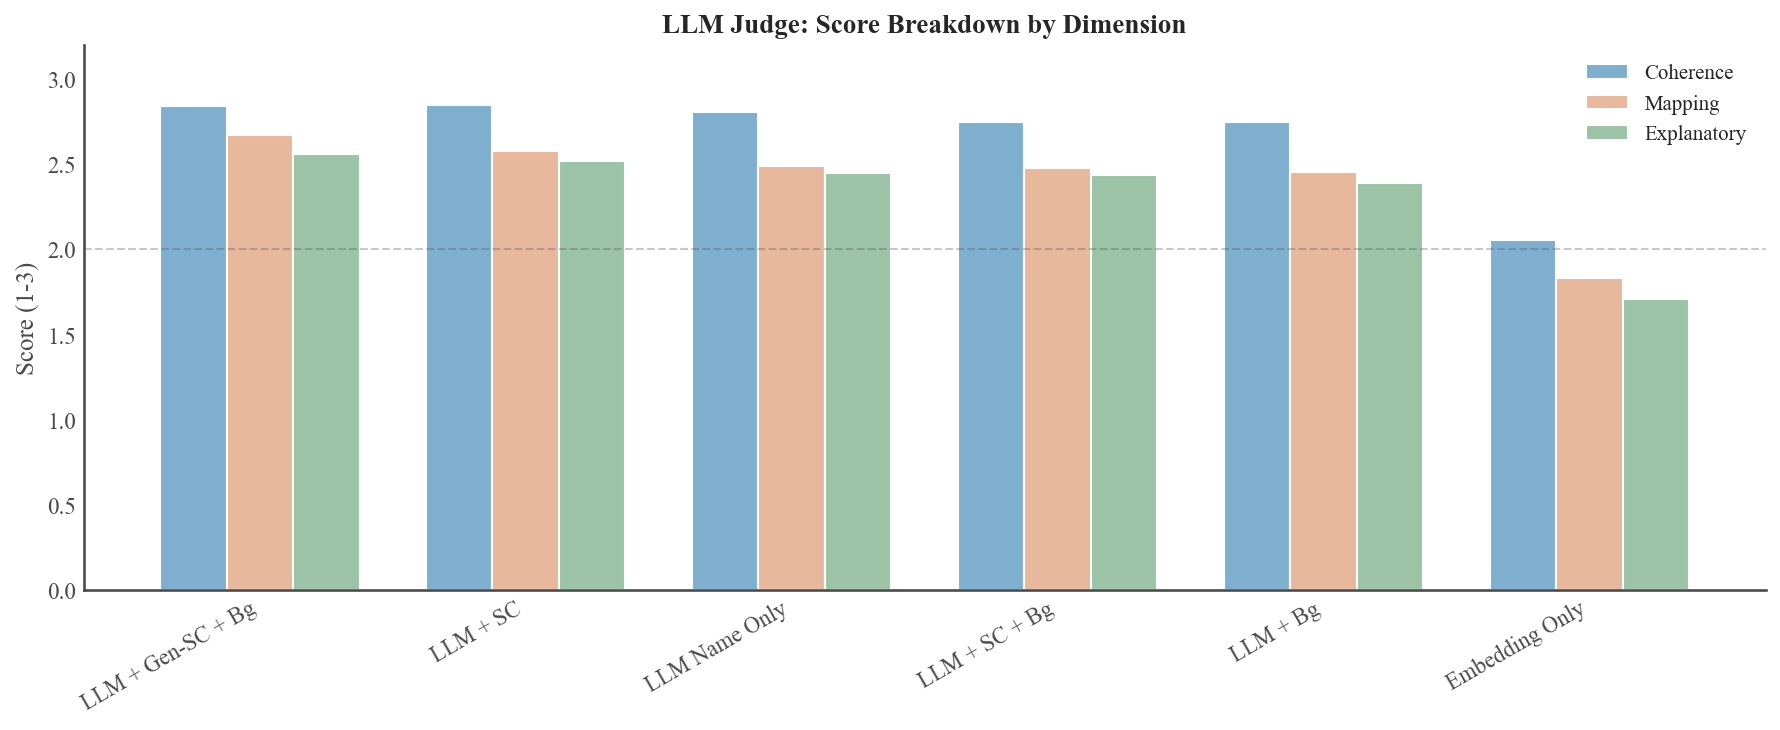

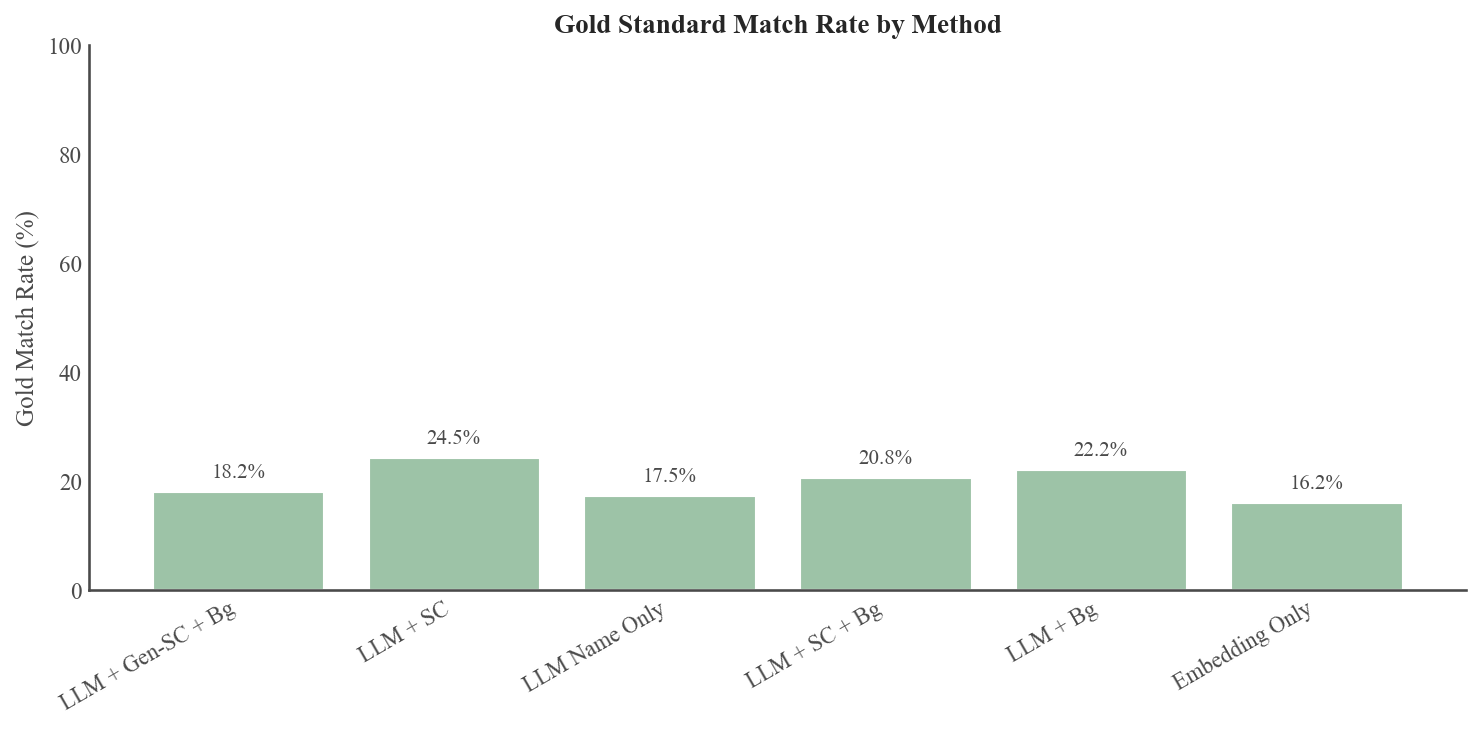

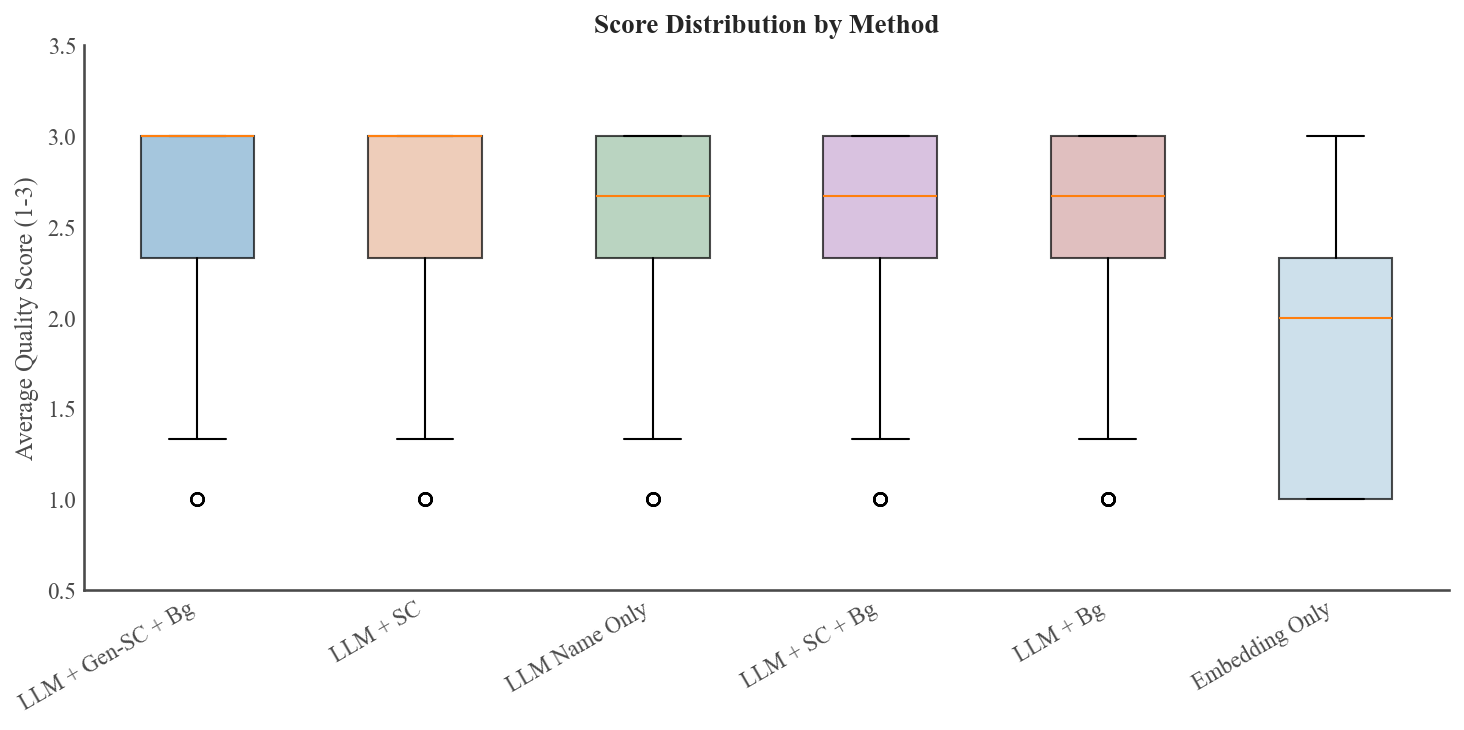


All visualizations saved to ACL_Vis/ folder


In [ ]:
# =============================================================================
# VISUALIZATION: ACL Paper Style - Method Comparison
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# ACL Paper Color Palette & Style Configuration
# =============================================================================
COLORS = {
    'primary': '#7FAFCF',      # Dusty Blue
    'secondary': '#E8B89D',    # Soft Peach
    'accent1': '#9DC3A7',      # Sage Green
    'accent2': '#C9A9D4',      # Lavender
    'dark': '#D4A5A5',         # Dusty Rose
    'text': '#4A4A4A',         # Soft Gray
}

PALETTE_MAIN = [COLORS['primary'], COLORS['secondary'], COLORS['accent1'], 
                COLORS['accent2'], COLORS['dark'], '#B8D4E3', '#F5D5C8']

# Set global matplotlib style - LARGER FONTS FOR PAPER
plt.style.use('seaborn-v0_8-white')
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Georgia']
rcParams['font.size'] = 16
rcParams['axes.labelsize'] = 18
rcParams['axes.titlesize'] = 20
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.labelcolor'] = COLORS['text']
rcParams['axes.edgecolor'] = COLORS['text']
rcParams['xtick.color'] = COLORS['text']
rcParams['ytick.color'] = COLORS['text']
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14
rcParams['legend.fontsize'] = 14
rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

# Create readable method names
METHOD_LABELS = {
    'baseline1_embedding_top3': 'Embedding Only',
    'baseline2_embedding_llm': 'LLM + SC',  # SC = Subconcepts
    'baseline2b_name_only': 'LLM Name Only',
    'baseline2c_full': 'LLM + SC + Bg',  # Bg = Background
    'baseline2d_name_desc': 'LLM + Bg',
    'pipeline_results': 'LLM + Gen-SC + Bg'  # Gen-SC = Generated Subconcepts
}

# Apply labels
successful['method'] = successful['source_file'].map(METHOD_LABELS)

# Sort by average score for consistent ordering
method_order = successful.groupby('method')['average_score'].mean().sort_values(ascending=False).index.tolist()

# =============================================================================
# Figure 1: Overall Method Comparison (Average Score)
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

avg_scores = successful.groupby('method')['average_score'].mean().reindex(method_order)
bars = ax1.bar(range(len(avg_scores)), avg_scores.values, color=PALETTE_MAIN[:len(avg_scores)], 
               edgecolor='white', linewidth=1.5)

ax1.set_xticks(range(len(avg_scores)))
ax1.set_xticklabels(avg_scores.index, rotation=30, ha='right')
ax1.set_ylabel('Average Quality Score (1-3)')
ax1.set_ylim(0, 3.2)
ax1.axhline(y=2, color=COLORS['text'], linestyle='--', alpha=0.3, linewidth=1)
ax1.set_title('LLM Judge: Average Analogy Quality by Method')

# Add value labels on bars
for bar, val in zip(bars, avg_scores.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{val:.2f}', ha='center', va='bottom', fontsize=14, color=COLORS['text'])

plt.tight_layout()
plt.savefig('ACL_Vis/fig_judge_avg_score.pdf', format='pdf', bbox_inches='tight')
plt.savefig('ACL_Vis/fig_judge_avg_score.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# Figure 2: Dimension Breakdown by Method
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(14, 6))

score_cols = ["analogy_coherence", "mapping_soundness", "explanatory_power"]
dim_labels = ["Coherence", "Mapping", "Explanatory"]

dim_means = successful.groupby('method')[score_cols].mean().reindex(method_order)

x = np.arange(len(method_order))
width = 0.25

for i, (col, label) in enumerate(zip(score_cols, dim_labels)):
    bars = ax2.bar(x + i*width, dim_means[col], width, label=label, 
                   color=PALETTE_MAIN[i], edgecolor='white', linewidth=1)

ax2.set_xticks(x + width)
ax2.set_xticklabels(method_order, rotation=30, ha='right')
ax2.set_ylabel('Score (1-3)')
ax2.set_ylim(0, 3.2)
ax2.axhline(y=2, color=COLORS['text'], linestyle='--', alpha=0.3, linewidth=1)
ax2.set_title('LLM Judge: Score Breakdown by Dimension')
ax2.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('ACL_Vis/fig_judge_dimensions.pdf', format='pdf', bbox_inches='tight')
plt.savefig('ACL_Vis/fig_judge_dimensions.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# Figure 3: Gold Match Rate Comparison
# =============================================================================
fig3, ax3 = plt.subplots(figsize=(12, 6))

match_rates = successful.groupby('method')['gold_match'].mean().reindex(method_order) * 100
bars = ax3.bar(range(len(match_rates)), match_rates.values, color=COLORS['accent1'], 
               edgecolor='white', linewidth=1.5)

ax3.set_xticks(range(len(match_rates)))
ax3.set_xticklabels(match_rates.index, rotation=30, ha='right')
ax3.set_ylabel('Gold Match Rate (%)')
ax3.set_ylim(0, 100)
ax3.set_title('Gold Standard Match Rate by Method')

# Add value labels
for bar, val in zip(bars, match_rates.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5, 
             f'{val:.1f}%', ha='center', va='bottom', fontsize=14, color=COLORS['text'])

plt.tight_layout()
plt.savefig('ACL_Vis/fig_judge_gold_match.pdf', format='pdf', bbox_inches='tight')
plt.savefig('ACL_Vis/fig_judge_gold_match.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# Figure 4: Score Distribution Comparison (Box Plot)
# =============================================================================
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Create box plot data
box_data = [successful[successful['method'] == m]['average_score'].values for m in method_order]

bp = ax4.boxplot(box_data, patch_artist=True, labels=method_order)

# Color the boxes
for patch, color in zip(bp['boxes'], PALETTE_MAIN[:len(method_order)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_ylabel('Average Quality Score (1-3)')
ax4.set_ylim(0.5, 3.5)
ax4.set_title('Score Distribution by Method')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('ACL_Vis/fig_judge_distribution.pdf', format='pdf', bbox_inches='tight')
plt.savefig('ACL_Vis/fig_judge_distribution.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAll visualizations saved to ACL_Vis/ folder")


In [9]:
# =============================================================================
# FINAL COMPARISON TABLE: Which Method is Best?
# =============================================================================

# Create comprehensive comparison table
comparison = successful.groupby('method').agg({
    'analogy_coherence': 'mean',
    'mapping_soundness': 'mean',
    'explanatory_power': 'mean',
    'average_score': 'mean',
    'gold_match': ['mean', 'sum'],
    'id': 'count'
}).round(3)

comparison.columns = ['Coherence', 'Mapping', 'Explanatory', 'Avg Score', 
                       'Gold Rate', 'Gold Matches', 'N']
comparison['Gold Rate'] = (comparison['Gold Rate'] * 100).round(1).astype(str) + '%'
comparison = comparison.sort_values('Avg Score', ascending=False)

print("="*80)
print("FINAL METHOD COMPARISON (Ranked by Average Score)")
print("="*80)
print(comparison.to_string())

# Identify best method
best_method = comparison.index[0]
best_score = comparison.loc[best_method, 'Avg Score']

print(f"\n{'='*80}")
print(f"BEST METHOD: {best_method}")
print(f"  Average Quality Score: {best_score:.3f} / 3.0")
print(f"  Gold Match Rate: {comparison.loc[best_method, 'Gold Rate']}")
print("="*80)

# Save comparison table
comparison.to_csv('llm_judge_method_comparison.csv')
print("\nComparison table saved to: llm_judge_method_comparison.csv")


FINAL METHOD COMPARISON (Ranked by Average Score)
                   Coherence  Mapping  Explanatory  Avg Score Gold Rate  Gold Matches    N
method                                                                                    
LLM + Gen-SC + Bg      2.842    2.670        2.562      2.691     18.2%            73  400
LLM + SC               2.845    2.575        2.520      2.646     24.5%            98  400
LLM Name Only          2.808    2.492        2.448      2.582     17.5%            70  400
LLM + SC + Bg          2.750    2.478        2.438      2.554     20.8%            83  400
LLM + Bg               2.748    2.452        2.392      2.530     22.2%            89  400
Embedding Only         2.055    1.832        1.710      1.865     16.2%            65  400

BEST METHOD: LLM + Gen-SC + Bg
  Average Quality Score: 2.691 / 3.0
  Gold Match Rate: 18.2%

Comparison table saved to: llm_judge_method_comparison.csv


In [ ]:
# I want to compare the same files with their hit@k and things from ACL_vizialize.ipynb
#compare the hit@k of all three settings. And also compare in 4 graphs how much of each rank was found (1-20 and -1). 

In [11]:
# =============================================================================
# LOAD GOLD RANK DATA: For Hit@K and Rank Distribution Analysis
# =============================================================================

# Re-use FILE_CONFIGS to load gold_rank from each baseline file
rank_data = {}

for source_name, config in FILE_CONFIGS.items():
    try:
        df = pd.read_csv(config["path"])
        rank_data[source_name] = df['gold_rank'].values
        print(f"Loaded gold_rank for {source_name}: {len(df)} records")
    except Exception as e:
        print(f"ERROR loading {source_name}: {e}")

# Convert to DataFrame for easier analysis
rank_df = pd.DataFrame(rank_data)
print(f"\nRank data shape: {rank_df.shape}")
print(f"\nSample gold_rank values:")
print(rank_df.head())


Loaded gold_rank for baseline1_embedding_top3: 400 records
Loaded gold_rank for baseline2_embedding_llm: 400 records
Loaded gold_rank for baseline2b_name_only: 400 records
Loaded gold_rank for baseline2c_full: 400 records
Loaded gold_rank for baseline2d_name_desc: 400 records
Loaded gold_rank for pipeline_results: 400 records

Rank data shape: (400, 6)

Sample gold_rank values:
   baseline1_embedding_top3  baseline2_embedding_llm  baseline2b_name_only  \
0                         1                        1                     1   
1                        -1                       -1                    -1   
2                        -1                       -1                    -1   
3                         3                        1                     1   
4                        -1                       -1                    -1   

   baseline2c_full  baseline2d_name_desc  pipeline_results  
0                1                     1                 1  
1               -1          

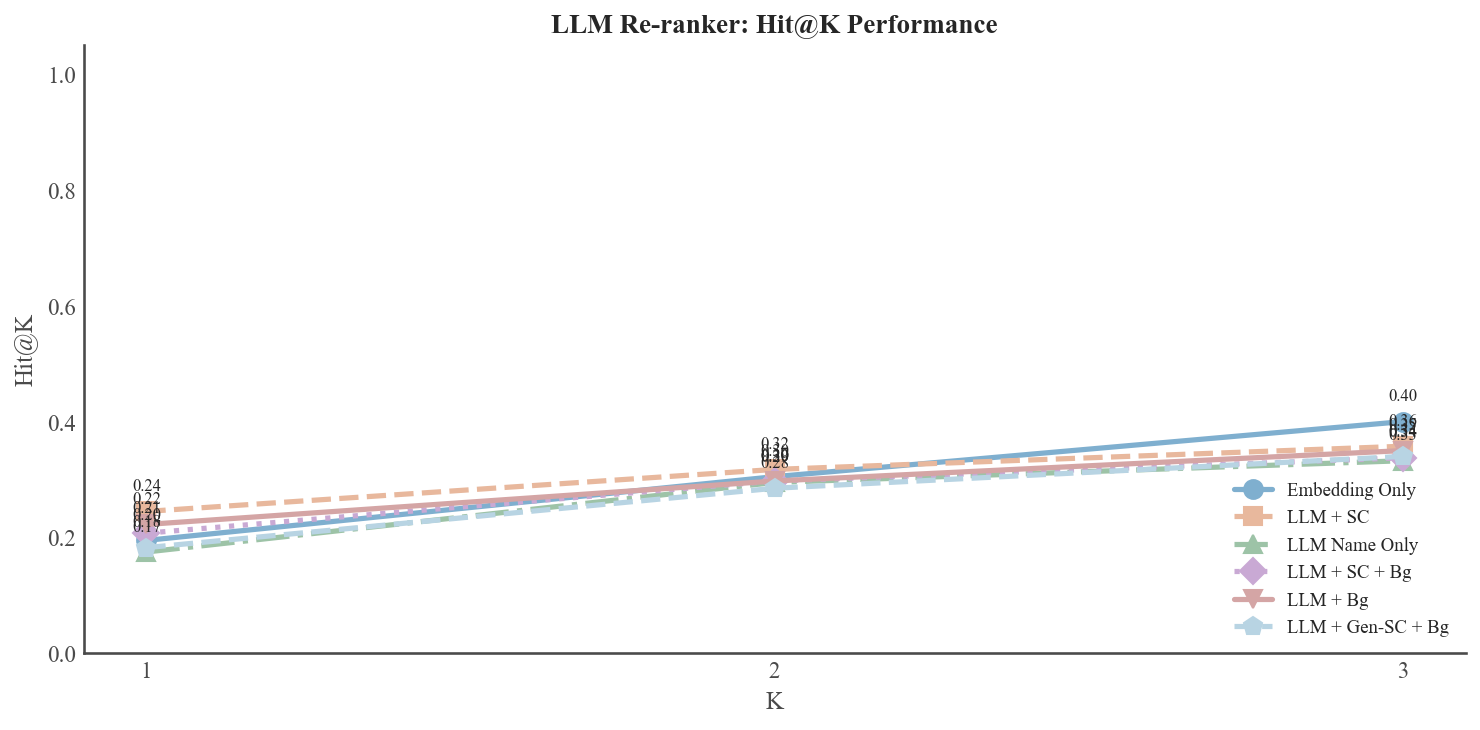


📊 LLM Re-ranker Hit@K Summary:
-----------------------------------------------------------------
Method               |    Hit@1 |    Hit@2 |    Hit@3
-----------------------------------------------------------------
Embedding Only       |    0.195 |    0.305 |    0.400
LLM + SC             |    0.245 |    0.318 |    0.357
LLM Name Only        |    0.175 |    0.295 |    0.333
LLM + SC + Bg        |    0.207 |    0.297 |    0.338
LLM + Bg             |    0.223 |    0.297 |    0.350
LLM + Gen-SC + Bg    |    0.182 |    0.285 |    0.340
-----------------------------------------------------------------


In [ ]:
# =============================================================================
# HIT@K CALCULATION AND LINE CHART
# =============================================================================

def calculate_hit_at_k(ranks, k_values=[1, 2, 3]):
    """Calculate Hit@K for various k values."""
    results = {}
    for k in k_values:
        hits = ((ranks >= 1) & (ranks <= k)).sum()
        results[k] = hits / len(ranks)
    return results

# Calculate Hit@K for each method
k_values = [1, 2, 3]
hit_at_k_results = {}
for method_name in rank_df.columns:
    ranks = rank_df[method_name]
    hit_at_k_results[method_name] = calculate_hit_at_k(ranks, k_values)

# Map to readable method names
hit_at_k_labeled = {}
for method_name, results in hit_at_k_results.items():
    label = METHOD_LABELS.get(method_name, method_name)
    hit_at_k_labeled[label] = results

# --- Hit@K Line Chart ---
fig, ax = plt.subplots(figsize=(12, 6))

line_styles = ['-', '--', '-.', ':', '-', '--']
markers = ['o', 's', '^', 'D', 'v', 'p']

for idx, (name, results) in enumerate(hit_at_k_labeled.items()):
    x_vals = list(results.keys())
    y_vals = list(results.values())
    ax.plot(x_vals, y_vals, marker=markers[idx % len(markers)], 
            linestyle=line_styles[idx % len(line_styles)], 
            color=PALETTE_MAIN[idx % len(PALETTE_MAIN)], 
            linewidth=2.5, markersize=10, label=name)
    for x, y in zip(x_vals, y_vals):
        ax.annotate(f'{y:.2f}', (x, y), textcoords="offset points", 
                    xytext=(0, 12), ha='center', fontsize=12)

ax.set_xlabel('K', fontsize=18)
ax.set_ylabel('Hit@K', fontsize=18)
ax.set_title('LLM Re-ranker: Hit@K Performance', fontweight='bold', fontsize=20)
ax.set_xticks(k_values)
ax.set_xticklabels(['1', '2', '3'], fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', framealpha=0.9, fontsize=13)
plt.tight_layout()
plt.savefig('ACL_Vis/fig_llm_reranker_hitk.pdf', format='pdf', bbox_inches='tight')
plt.savefig('ACL_Vis/fig_llm_reranker_hitk.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n📊 LLM Re-ranker Hit@K Summary:")
print("-" * 65)
print(f"{'Method':<20} | {'Hit@1':>8} | {'Hit@2':>8} | {'Hit@3':>8}")
print("-" * 65)
for name, results in hit_at_k_labeled.items():
    print(f"{name:<20} | {results[1]:>8.3f} | {results[2]:>8.3f} | {results[3]:>8.3f}")
print("-" * 65)


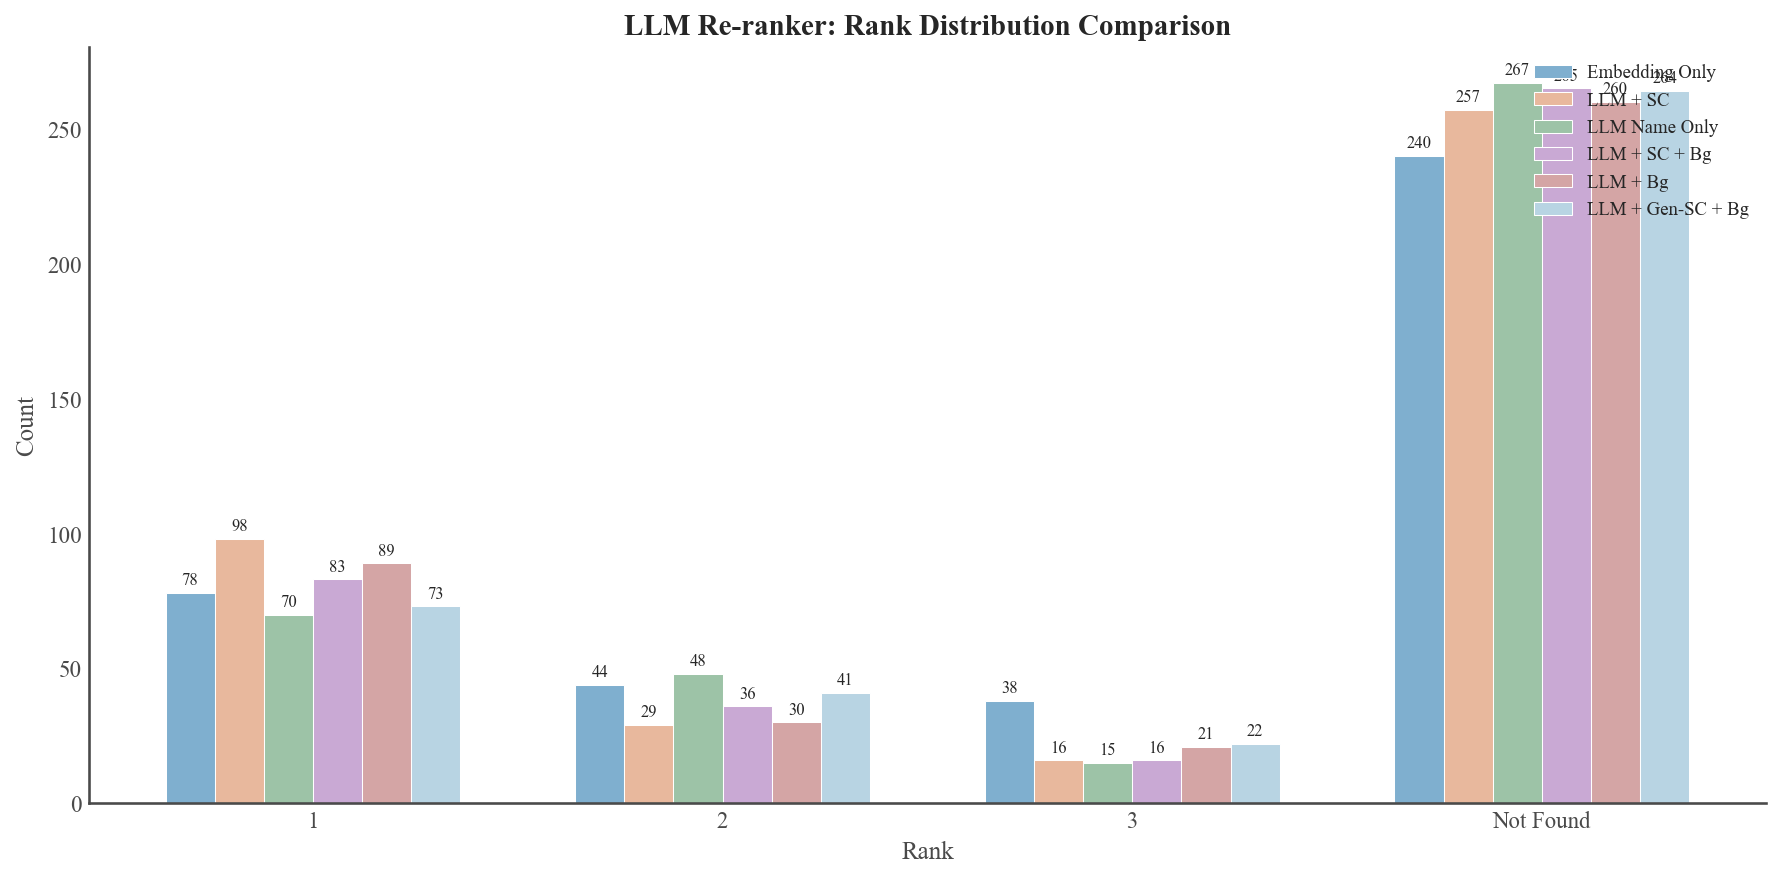


📊 Rank Distribution Comparison (All Methods):
----------------------------------------------------------------------------------------------------
Rank         Embedding Only       LLM + SC  LLM Name Only  LLM + SC + Bg       LLM + BgLLM + Gen-SC + Bg
----------------------------------------------------------------------------------------------------
1                        78             98             70             83             89             73
2                        44             29             48             36             30             41
3                        38             16             15             16             21             22
Not Found               240            257            267            265            260            264
----------------------------------------------------------------------------------------------------

📊 Found Rate (Not rank -1):
   Embedding Only      : 40.0% found (160/400)
   LLM + SC            : 35.8% found (143/400)
   LLM Nam

In [ ]:
# =============================================================================
# RANK DISTRIBUTION: Grouped Bar Chart (1, 2, 3, Not Found)
# =============================================================================

# Calculate rank distribution for each method
rank_labels = ['1', '2', '3', 'Not Found']

rank_counts = {}
for method_name in rank_df.columns:
    ranks = rank_df[method_name]
    label = METHOD_LABELS.get(method_name, method_name)
    counts = [
        (ranks == 1).sum(),
        (ranks == 2).sum(),
        (ranks == 3).sum(),
        (ranks == -1).sum()
    ]
    rank_counts[label] = counts

method_names = list(rank_counts.keys())

# --- Grouped Bar Chart ---
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(rank_labels))
n_methods = len(method_names)
width = 0.12  # Width of each bar
offsets = np.linspace(-(n_methods-1)*width/2, (n_methods-1)*width/2, n_methods)

for idx, (method, counts) in enumerate(rank_counts.items()):
    bars = ax.bar(x + offsets[idx], counts, width, 
                  label=method, color=PALETTE_MAIN[idx % len(PALETTE_MAIN)], 
                  edgecolor='white', linewidth=0.5)
    
    # Add count labels on top of each bar
    for bar, count in zip(bars, counts):
        if count > 0:
            ax.annotate(f'{int(count)}', 
                       xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       xytext=(0, 2), textcoords="offset points", 
                       ha='center', va='bottom', fontsize=11, rotation=0)

ax.set_xlabel('Rank', fontsize=18)
ax.set_ylabel('Count', fontsize=18)
ax.set_title('LLM Re-ranker: Rank Distribution Comparison', fontweight='bold', fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(rank_labels, fontsize=14)
ax.legend(loc='upper right', framealpha=0.95, fontsize=13)

plt.tight_layout()
plt.savefig('ACL_Vis/fig_llm_reranker_rank_distribution.pdf', format='pdf', bbox_inches='tight')
plt.savefig('ACL_Vis/fig_llm_reranker_rank_distribution.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison table
print("\n📊 Rank Distribution Comparison (All Methods):")
print("-" * 100)
header = f"{'Rank':<12}" + "".join([f"{name:>15}" for name in method_names])
print(header)
print("-" * 100)
for i, label in enumerate(rank_labels):
    row = f"{label:<12}" + "".join([f"{rank_counts[name][i]:>15}" for name in method_names])
    print(row)
print("-" * 100)

# Calculate and print found percentages
print("\n📊 Found Rate (Not rank -1):")
for method_name in rank_df.columns:
    ranks = rank_df[method_name]
    label = METHOD_LABELS.get(method_name, method_name)
    found = (ranks != -1).sum()
    found_pct = found / len(ranks) * 100
    print(f"   {label:<20}: {found_pct:.1f}% found ({found}/{len(ranks)})")


In [14]:
# =============================================================================
# UNIFIED COMPARISON TABLE: Automatic Metrics + LLM Quality Scores
# =============================================================================

# Build unified table combining Hit@K (automatic) with LLM judge scores
unified_data = []

for source_name in FILE_CONFIGS.keys():
    method_label = METHOD_LABELS.get(source_name, source_name)
    
    # Get Hit@K from rank data
    ranks = rank_df[source_name]
    hit1 = ((ranks >= 1) & (ranks <= 1)).sum() / len(ranks)
    hit2 = ((ranks >= 1) & (ranks <= 2)).sum() / len(ranks)
    hit3 = ((ranks >= 1) & (ranks <= 3)).sum() / len(ranks)
    found_rate = (ranks != -1).sum() / len(ranks)
    
    # Get LLM judge scores from successful evaluations
    method_data = successful[successful['source_file'] == source_name]
    coherence = method_data['analogy_coherence'].mean()
    mapping = method_data['mapping_soundness'].mean()
    explanatory = method_data['explanatory_power'].mean()
    avg_score = method_data['average_score'].mean()
    gold_match_rate = method_data['gold_match'].mean()
    
    unified_data.append({
        'Method': method_label,
        'Hit@1': hit1,
        'Hit@2': hit2,
        'Hit@3': hit3,
        'Found Rate': found_rate,
        'Coherence': coherence,
        'Mapping': mapping,
        'Explanatory': explanatory,
        'Avg Score': avg_score,
        'Gold Match': gold_match_rate
    })

unified_df = pd.DataFrame(unified_data)

# Sort by Avg Score (LLM quality) descending
unified_df = unified_df.sort_values('Avg Score', ascending=False).reset_index(drop=True)

# Format for display
display_df = unified_df.copy()
display_df['Hit@1'] = display_df['Hit@1'].apply(lambda x: f'{x:.1%}')
display_df['Hit@2'] = display_df['Hit@2'].apply(lambda x: f'{x:.1%}')
display_df['Hit@3'] = display_df['Hit@3'].apply(lambda x: f'{x:.1%}')
display_df['Found Rate'] = display_df['Found Rate'].apply(lambda x: f'{x:.1%}')
display_df['Coherence'] = display_df['Coherence'].apply(lambda x: f'{x:.2f}')
display_df['Mapping'] = display_df['Mapping'].apply(lambda x: f'{x:.2f}')
display_df['Explanatory'] = display_df['Explanatory'].apply(lambda x: f'{x:.2f}')
display_df['Avg Score'] = display_df['Avg Score'].apply(lambda x: f'{x:.2f}')
display_df['Gold Match'] = display_df['Gold Match'].apply(lambda x: f'{x:.1%}')

print("=" * 120)
print("UNIFIED COMPARISON: Automatic Metrics (Hit@K) + LLM Quality Scores")
print("=" * 120)
print(display_df.to_string(index=False))
print("=" * 120)

# Save to CSV
unified_df.to_csv('unified_method_comparison.csv', index=False)
print("\nUnified comparison table saved to: unified_method_comparison.csv")

# Print insights
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
best_hitk = unified_df.loc[unified_df['Hit@1'].idxmax()]
best_quality = unified_df.loc[unified_df['Avg Score'].idxmax()]
print(f"Best Hit@1:        {best_hitk['Method']} ({best_hitk['Hit@1']:.1%})")
print(f"Best LLM Quality:  {best_quality['Method']} (Avg Score: {best_quality['Avg Score']:.2f})")

# Check if same method is best for both
if best_hitk['Method'] == best_quality['Method']:
    print(f"\n✓ Same method ({best_hitk['Method']}) leads in both automatic and LLM-based evaluation!")
else:
    print(f"\n⚠ Different methods lead: {best_hitk['Method']} for Hit@1, {best_quality['Method']} for LLM quality")
    print("  This suggests Hit@1 (matching gold standard) and LLM quality scores measure different aspects.")


UNIFIED COMPARISON: Automatic Metrics (Hit@K) + LLM Quality Scores
           Method Hit@1 Hit@2 Hit@3 Found Rate Coherence Mapping Explanatory Avg Score Gold Match
LLM + Gen-SC + Bg 18.2% 28.5% 34.0%      34.0%      2.84    2.67        2.56      2.69      18.2%
         LLM + SC 24.5% 31.8% 35.8%      35.8%      2.85    2.58        2.52      2.65      24.5%
    LLM Name Only 17.5% 29.5% 33.2%      33.2%      2.81    2.49        2.45      2.58      17.5%
    LLM + SC + Bg 20.8% 29.8% 33.8%      33.8%      2.75    2.48        2.44      2.55      20.8%
         LLM + Bg 22.2% 29.8% 35.0%      35.0%      2.75    2.45        2.39      2.53      22.2%
   Embedding Only 19.5% 30.5% 40.0%      40.0%      2.06    1.83        1.71      1.87      16.2%

Unified comparison table saved to: unified_method_comparison.csv

KEY INSIGHTS
Best Hit@1:        LLM + SC (24.5%)
Best LLM Quality:  LLM + Gen-SC + Bg (Avg Score: 2.69)

⚠ Different methods lead: LLM + SC for Hit@1, LLM + Gen-SC + Bg for LLM qua